# Data Visualization with Matplotlib and Seaborn

Raw numbers, averages, and statistics are useful, but humans are visual creatures. A single well-crafted chart can instantly reveal trends, correlations, distributions, and outliers that might remain hidden in a raw table of data. 

In Python, the industry standards for data visualization are **Matplotlib** and **Seaborn**.

---

## 1. Matplotlib vs. Seaborn: When to Use Which?

*   **Matplotlib**: The foundational library. It is low-level, highly customizable, and behaves like MATLAB. It gives you absolute control over every single pixel of your chart.
*   **Seaborn**: A high-level library built on top of Matplotlib. It is tightly integrated with Pandas DataFrames, uses beautiful default styles, and is designed to create complex statistical plots (like box plots, distribution plots, and heatmaps) with very little code.

*Rule of thumb*: Use **Seaborn** to quickly create stunning, complex statistical charts, and use **Matplotlib** to fine-tune the labels, layout, and fine details.

---

## 2. Matplotlib: The Building Blocks

To write clean code, we import Matplotlib's plotting interface, `pyplot`, as `plt`:




In [35]:
import matplotlib.pyplot as plt




### The Anatomy of a Figure
In Matplotlib, a chart is composed of two main concepts:
- **`Figure`**: The overall canvas (like the window or file containing the drawing).
- **`Axes`**: The individual plot inside the canvas (a figure can have multiple axes, e.g., a grid of subplots).




In [36]:
# Create a figure with a custom size (width=8 inches, height=5 inches)
fig, ax = plt.subplots(figsize=(8, 5))

# Plot a simple line
ax.plot([1, 2, 3, 4], [10, 24, 36, 48], color="royalblue", linewidth=2, marker="o")

# Customize labels & title
ax.set_title("Monthly Revenue Growth", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Revenue ($)", fontsize=12)

# Enable grid lines for easier readability
ax.grid(True, linestyle="--", alpha=0.6)

# Display the plot in a window (if running in a desktop GUI environment)
# plt.show()

# Save the plot as a high-resolution PNG file (essential for pipelines and web apps!)
plt.savefig("revenue_growth.png", dpi=300, bbox_inches="tight")

# Always close the plot to free up system RAM
plt.close()




### Standard Plots in Matplotlib



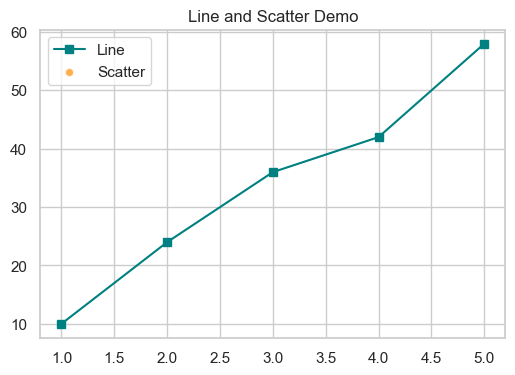

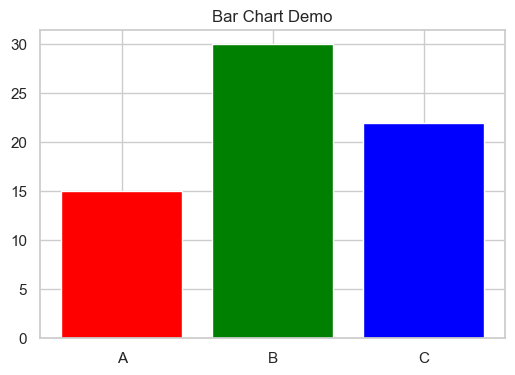

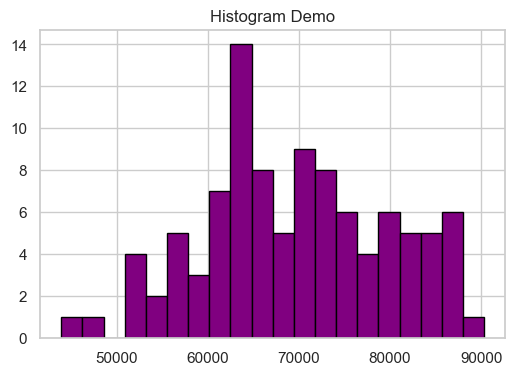

In [37]:
# Create sample data for Matplotlib standard plots
x = np.array([1, 2, 3, 4, 5])
y = np.array([10, 24, 36, 42, 58])
categories = ['A', 'B', 'C']
values = [15, 30, 22]
data = np.random.normal(70000, 10000, 100)

# 1. Line Plot & 2. Scatter Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, linestyle='-', marker='s', color='teal', label='Line')
ax.scatter(x, y, color='darkorange', alpha=0.7, edgecolors='white', label='Scatter')
ax.set_title('Line and Scatter Demo')
ax.legend()
plt.show()
plt.close()

# 3. Bar Chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(categories, values, color=['red', 'green', 'blue'])
ax.set_title('Bar Chart Demo')
plt.show()
plt.close()

# 4. Histogram
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(data, bins=20, color='purple', edgecolor='black')
ax.set_title('Histogram Demo')
plt.show()
plt.close()




---

## 3. Seaborn: Advanced Statistical Plots

We import Seaborn as `sns` and usually activate its default styling themes:




In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Apply Seaborn's elegant styling theme
sns.set_theme(style="whitegrid")




Because Seaborn works directly with Pandas DataFrames, you simply pass the DataFrame to `data` and specify which column names to use for the `x` and `y` axes:




In [39]:
# Create a sample DataFrame for Seaborn plot demonstrations
df = pd.DataFrame({
    'Height': [165, 175, 180, 160, 170, 185],
    'Weight': [60, 75, 80, 55, 65, 88],
    'Gender': ['Female', 'Male', 'Male', 'Female', 'Female', 'Male'],
    'Year': [2018, 2019, 2020, 2021, 2022, 2023],
    'GDP': [1.2, 1.4, 1.3, 1.6, 1.8, 2.0],
    'Region': ['North', 'North', 'South', 'North', 'South', 'South'],
    'Salary': [50000, 62000, 75000, 80000, 95000, 110000],
    'Age': [25, 30, 35, 40, 45, 50],
    'Department': ['IT', 'Sales', 'IT', 'HR', 'Sales', 'IT'],
    'Education': ['BSc', 'MSc', 'BSc', 'PhD', 'MSc', 'PhD'],
    'Group': ['G1', 'G1', 'G2', 'G2', 'G1', 'G2'],
    'TestScore': [88, 92, 79, 85, 90, 95]
})

# Scatter plot colored dynamically by a third category (Hue)
sns.scatterplot(data=df, x="Height", y="Weight", hue="Gender", palette="Set2")
plt.savefig("scatter.png")
plt.close()




### Essential Seaborn Charts

#### A. Relational Plots (Trends and Patterns)



<Axes: xlabel='Year', ylabel='GDP'>

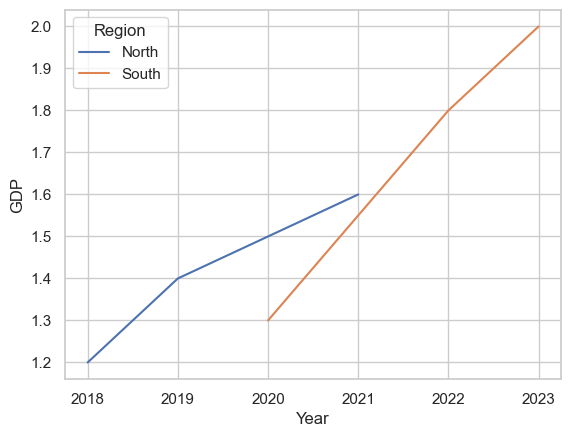

In [40]:
# Line plot with dynamic error bands for multi-observation datasets
sns.lineplot(data=df, x="Year", y="GDP", hue="Region")




#### B. Distribution Plots



<Axes: xlabel='Salary', ylabel='Count'>

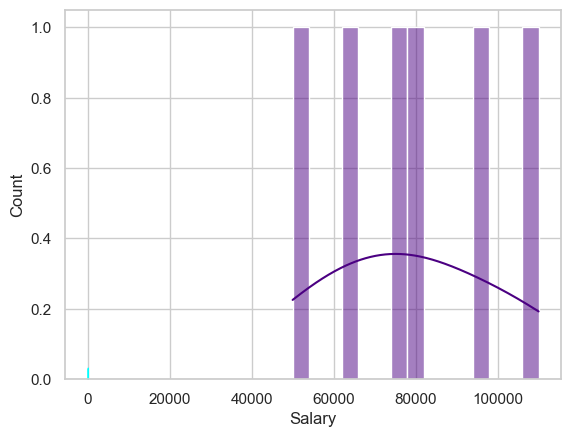

In [41]:
# Histogram overlaid with a smooth Kernel Density Estimate (KDE) curve
sns.histplot(data=df, x="Salary", kde=True, color="indigo", bins=15)

# Pure Density Curve
sns.kdeplot(data=df, x="Age", fill=True, color="cyan")




#### C. Categorical Comparisons



C:\Users\hamza\AppData\Local\Temp\ipykernel_20564\2742878870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Department", y="Salary", palette="muted")


<Axes: xlabel='Department', ylabel='Salary'>

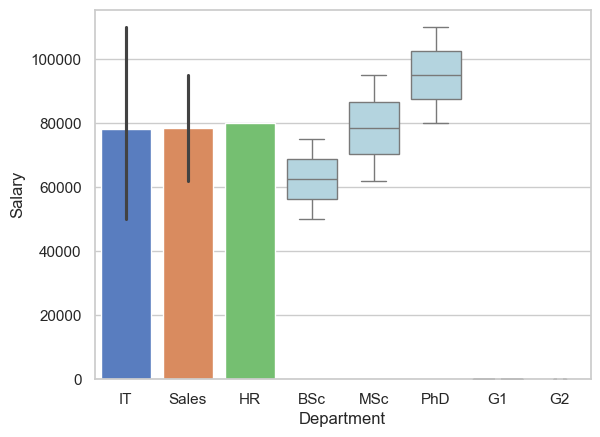

In [42]:
# Bar chart (automatically computes average and displays confidence interval bars!)
sns.barplot(data=df, x="Department", y="Salary", palette="muted")

# Box plot: Instantly visualizes Median, IQR (25th and 75th percentiles), and Outliers
sns.boxplot(data=df, x="Education", y="Salary", color="lightblue")

# Violin plot: Combines box plot and density estimation to show distribution shapes
sns.violinplot(data=df, x="Group", y="TestScore")




#### D. Matrix Plots (Correlation Analysis)
A heatmap is the ultimate tool to visualize correlations between numerical features in a dataset:




<Axes: >

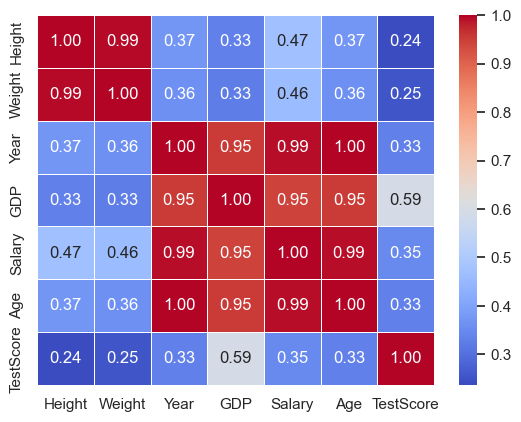

In [43]:
# Calculate correlation matrix
corr = df.corr(numeric_only=True)

# Generate heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)




---

## 4. Subplots: Grids of Charts
If you want to present multiple charts next to each other in a clean layout:




In [44]:
# Create a grid of 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot on the first axes (left)
sns.histplot(data=df, x="Age", ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Age Distribution")

# Plot on the second axes (right)
sns.scatterplot(data=df, x="Age", y="Salary", ax=axes[1], color="salmon")
axes[1].set_title("Salary vs. Age")

# Automatically adjust layout spacing to prevent label overlapping
plt.tight_layout()
plt.savefig("demographics_dashboard.png")
plt.close()




---

## 5. Professional Visualization Checklist

1.  **Always Add Context**: A chart without axis labels (`xlabel`, `ylabel`) or a `title` is useless.
2.  **Color with Purpose**: Use color to highlight important points or differentiate categories. Avoid using a rainbow of colors without meaning.
3.  **Choose the Right Export Format**:
    *   **PNG**: Perfect for standard images (`dpi=300` is professional print-quality).
    *   **PDF/SVG**: Vector formats. They never get pixelated, making them perfect for academic papers or website graphics.
4.  **Avoid Crowding**: Let the data breathe. Remove unnecessary borders ("spines") or adjust label sizes so readers can scan the figure in under 3 seconds.
5.  **Always Close Figures**: Use `plt.close()` at the end of scripts. If you are generating thousands of plots in a loop, failing to close them will crash your system due to memory leaks.

## Resources

- **Official Matplotlib Documentation** – https://matplotlib.org/stable/contents.html
- **Official Seaborn Documentation** – https://seaborn.pydata.org/
- **Real Python: Data Visualization with Matplotlib & Seaborn** – https://realpython.com/python-matplotlib-guide/
- **Python Graph Gallery** – https://python-graph-gallery.com/
- **Towards Data Science: Visualization Guides** – https://towardsdatascience.com/tagged/data-visualization
- **Kaggle: Data Visualization Courses** – https://www.kaggle.com/learn/data-visualization



# Examples & Demonstrations
Below are runnable examples demonstrating the concepts covered in this module.


In [45]:
# Examples: Data Visualization in Python

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set output directory to ensure saved plots are grouped together
OUTPUT_DIR = os.path.join(os.getcwd(), "plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Generate dummy company data for our visualizations
np.random.seed(42)
departments = ["IT", "Sales", "Marketing", "HR"]
data = {
    "EmployeeID": [f"EMP{i:03}" for i in range(1, 101)],
    "Department": np.random.choice(departments, 100),
    "Age": np.random.randint(22, 60, 100),
    "Salary": np.random.normal(75000, 15000, 100).round(-2),
    "YearsOfExperience": np.random.randint(1, 20, 100),
    "SatisfactionScore": np.random.uniform(2.0, 10.0, 100).round(1)
}
df_employees = pd.DataFrame(data)

# Make sure salary correlates somewhat with experience for realistic plots
df_employees["Salary"] += df_employees["YearsOfExperience"] * 2500


In [46]:
def matplotlib_basics_demo():
    print("\n--- 1. Running Matplotlib Basics Demo ---")
    
    # Let's generate a simple sequence (e.g. 12 months of sales)
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    sales = [12000, 15000, 14000, 18000, 22000, 21000, 25000, 28000, 26000, 31000, 35000, 42000]
    expenses = [9000, 10000, 11000, 12000, 14000, 13000, 15000, 16000, 15500, 18000, 20000, 25000]
    
    # Create figure & axes
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot Sales (Line with blue circles) and Expenses (Dashed line with red squares)
    ax.plot(months, sales, marker="o", color="royalblue", linewidth=2.5, label="Sales ($)")
    ax.plot(months, expenses, marker="s", linestyle="--", color="crimson", linewidth=2, label="Expenses ($)")
    
    # Title & Labels
    ax.set_title("Annual Financial Performance (2025)", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Month", fontsize=12)
    ax.set_ylabel("Amount ($)", fontsize=12)
    
    # Add grid lines
    ax.grid(True, linestyle=":", alpha=0.6)
    
    # Add legend
    ax.legend(fontsize=11, loc="upper left")
    
    # Save plot
    output_path = os.path.join(OUTPUT_DIR, "matplotlib_line_chart.png")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()
    
    print(f"  -> Saved Line Chart to: {output_path}")


In [47]:
def seaborn_statistical_demo(df):
    print("\n--- 2. Running Seaborn Statistical Demo ---")
    
    # Set the elegant Seaborn grid theme
    sns.set_theme(style="whitegrid")
    
    # Plot A: Salary Distribution (Histplot + KDE curve)
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x="Salary", kde=True, color="teal", bins=15)
    plt.title("Employee Salary Distribution (With KDE)", fontsize=13, fontweight="bold")
    plt.xlabel("Salary ($)")
    plt.ylabel("Frequency")
    
    output_path_a = os.path.join(OUTPUT_DIR, "seaborn_salary_distribution.png")
    plt.savefig(output_path_a, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"  -> Saved Salary Distribution Chart to: {output_path_a}")
    
    # Plot B: Salary by Department (Boxplot showing IQR and median)
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="Department", y="Salary", hue="Department", palette="Set2", legend=False)
    plt.title("Salary Ranges by Department", fontsize=13, fontweight="bold")
    plt.xlabel("Department")
    plt.ylabel("Salary ($)")
    
    output_path_b = os.path.join(OUTPUT_DIR, "seaborn_department_boxplot.png")
    plt.savefig(output_path_b, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"  -> Saved Department Box Plot to: {output_path_b}")


In [48]:
def multi_plot_dashboard(df):
    print("\n--- 3. Running Multi-plot Dashboard Demo ---")
    
    # Create a 2x2 grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Bar Plot: Average Salary by Department (Top Left)
    sns.barplot(data=df, x="Department", y="Salary", ax=axes[0, 0], hue="Department", palette="muted", legend=False, errorbar="ci")
    axes[0, 0].set_title("Average Salary by Department (with CI error bars)", fontsize=12, fontweight="bold")
    axes[0, 0].set_xlabel("Department")
    axes[0, 0].set_ylabel("Avg Salary ($)")
    
    # 2. Scatter Plot: Years of Experience vs. Salary colored by Department (Top Right)
    sns.scatterplot(
        data=df, x="YearsOfExperience", y="Salary", hue="Department", 
        size="SatisfactionScore", sizes=(20, 200), ax=axes[0, 1], palette="deep"
    )
    axes[0, 1].set_title("Experience vs. Salary (Size = Satisfaction)", fontsize=12, fontweight="bold")
    axes[0, 1].set_xlabel("Years of Experience")
    axes[0, 1].set_ylabel("Salary ($)")
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc="upper left") # move legend outside plot area
    
    # 3. Kernel Density Estimate: Age vs. Satisfaction (Bottom Left)
    sns.kdeplot(data=df, x="Age", fill=True, color="indigo", ax=axes[1, 0])
    axes[1, 0].set_title("Employee Age Density Curve", fontsize=12, fontweight="bold")
    axes[1, 0].set_xlabel("Age")
    axes[1, 0].set_ylabel("Density")
    
    # 4. Heatmap: Numerical Correlation Matrix (Bottom Right)
    # Calculate correlation matrix for numeric columns only
    corr_matrix = df[["Age", "Salary", "YearsOfExperience", "SatisfactionScore"]].corr()
    
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1, ax=axes[1, 1])
    axes[1, 1].set_title("Feature Correlation Heatmap", fontsize=12, fontweight="bold")
    
    # Adjust overall layout spacing
    plt.tight_layout()
    
    # Save the composite dashboard
    output_path = os.path.join(OUTPUT_DIR, "company_analytics_dashboard.png")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()
    
    print(f"  -> Saved Multi-plot Dashboard to: {output_path}")


In [49]:
print("=== STARTING DATA VISUALIZATION DEMO ===")
matplotlib_basics_demo()
seaborn_statistical_demo(df_employees)
multi_plot_dashboard(df_employees)
print("\nVisualizations successfully saved as PNG files under: ./plots/")
print("==================================================================")


=== STARTING DATA VISUALIZATION DEMO ===

--- 1. Running Matplotlib Basics Demo ---
  -> Saved Line Chart to: c:\Users\hamza\Desktop\repos\python_4_all\14_data_science_basics\data_visualization\plots\matplotlib_line_chart.png

--- 2. Running Seaborn Statistical Demo ---
  -> Saved Salary Distribution Chart to: c:\Users\hamza\Desktop\repos\python_4_all\14_data_science_basics\data_visualization\plots\seaborn_salary_distribution.png
  -> Saved Department Box Plot to: c:\Users\hamza\Desktop\repos\python_4_all\14_data_science_basics\data_visualization\plots\seaborn_department_boxplot.png

--- 3. Running Multi-plot Dashboard Demo ---
  -> Saved Multi-plot Dashboard to: c:\Users\hamza\Desktop\repos\python_4_all\14_data_science_basics\data_visualization\plots\company_analytics_dashboard.png

Visualizations successfully saved as PNG files under: ./plots/


# Practice Exercises
EXERCISES: The Visual Wizard

This script contains 3 practical exercises on data visualization in Matplotlib and Seaborn.
Complete the TODO sections to solve them. All outputs must be saved to the `./plots/` directory.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set output directory to save exercise plots
OUTPUT_DIR = os.path.join(os.getcwd(), "plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)


# =====================================================================
# EXERCISE 1: Stock Price Tracker (Matplotlib)
# =====================================================================
# Below is mock data for two rival companies' stock price movements over a week.
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
tech_corp_prices = [150.20, 152.10, 151.00, 154.50, 155.00]
green_energy_prices = [145.00, 144.50, 146.20, 145.80, 148.00]

print("=== Running Exercise 1 ===")

# TODO 1: Create a figure and axes with custom size (9, 5)
fig, ax = plt.subplots(figsize=(9, 5))

# TODO 2: Plot TechCorp prices as a solid line with circular markers ('o') in 'royalblue'
ax.plot(days, tech_corp_prices, marker="o", linestyle="-", color="royalblue", linewidth=2.5, label="TechCorp")

# TODO 3: Plot GreenEnergy prices as a dashed line with square markers ('s') in 'forestgreen'
ax.plot(days, green_energy_prices, marker="s", linestyle="--", color="forestgreen", linewidth=2, label="GreenEnergy")

# TODO 4: Add descriptive labels for the X-axis ('Day of the Week'), Y-axis ('Stock Price ($)'), and Title ('Weekly Stock Price Comparison')
ax.set_xlabel("Day of the Week", fontsize=11)
ax.set_ylabel("Stock Price ($)", fontsize=11)
ax.set_title("Weekly Stock Price Comparison", fontsize=13, fontweight="bold", pad=12)

# TODO 5: Enable dotted grid lines and add a legend positioned at the top left
ax.grid(True, linestyle=":", alpha=0.7)
ax.legend(loc="upper left")

# TODO 6: Save the plot as 'exercise1_stocks.png' inside the OUTPUT_DIR and close the figure
output_path1 = os.path.join(OUTPUT_DIR, "exercise1_stocks.png")
plt.savefig(output_path1, dpi=300, bbox_inches="tight")
plt.close()

print(f"  -> Saved Stock Tracker chart to: {output_path1}")
print("-" * 50)


# =====================================================================
# EXERCISE 2: Academic Grade Inspector (Seaborn)
# =====================================================================
# Below is mock exam data across three courses.
grades_data = {
    "StudentName": [
        "Hamza", "Ali", "Sara", "Hiba", "Omar", "Noor", 
        "John", "Jane", "Dwight", "Jim", "Pam", "Michael"
    ],
    "Subject": ["Math", "Physics", "Math", "Chemistry", "Physics", "Chemistry", "Math", "Physics", "Math", "Physics", "Chemistry", "Math"],
    "Score": [88, 92, 79, 95, 62, 85, 91, 88, 76, 84, 89, 70]
}
df_grades = pd.DataFrame(grades_data)

print("\n=== Running Exercise 2 ===")

# Set Seaborn theme style to 'white'
sns.set_theme(style="white")

# TODO 1: Create a new figure with size (8, 5)
plt.figure(figsize=(8, 5))

# TODO 2: Create a Boxplot showing scores by Subject. Set palette to 'pastel'
sns.boxplot(data=df_grades, x="Subject", y="Score", hue="Subject", palette="pastel", legend=False, width=0.5)

# TODO 3: Overplot individual student scores on top of the boxes using sns.stripplot
# Set jitter=True, size=6, color='black', and alpha=0.6 so the actual data points are clearly visible
sns.stripplot(data=df_grades, x="Subject", y="Score", color="black", jitter=True, size=6, alpha=0.6)

# TODO 4: Add a title 'Exam Scores by Subject (with raw data points)'
plt.title("Exam Scores by Subject (with raw data points)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Subject")
plt.ylabel("Exam Score")

# TODO 5: Save the plot as 'exercise2_grades.png' inside the OUTPUT_DIR and close the figure
output_path2 = os.path.join(OUTPUT_DIR, "exercise2_grades.png")
plt.savefig(output_path2, dpi=300, bbox_inches="tight")
plt.close()

print(f"  -> Saved Grade Inspector chart to: {output_path2}")
print("-" * 50)


# =====================================================================
# EXERCISE 3: Marketing ROI Analyst (Subplot Grid)
# =====================================================================
# Below is mock data representing regional advertising campaigns budgets and corresponding sales.
ad_data = {
    "Campaign": [f"Camp_{i:02}" for i in range(1, 16)],
    "TVBudget": [25, 45, 12, 60, 30, 8, 50, 40, 18, 55, 35, 20, 48, 65, 28],
    "SocialMediaBudget": [40, 15, 50, 10, 35, 48, 12, 28, 60, 22, 45, 30, 18, 5, 55],
    "Sales": [120, 145, 110, 160, 130, 102, 152, 140, 118, 158, 135, 122, 150, 164, 132]
}
df_ad = pd.DataFrame(ad_data)

print("\n=== Running Exercise 3 ===")

# TODO 1: Create a figure with 1 row and 2 columns, custom size (14, 5)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO 2: On axes[0] (left plot), draw a Seaborn scatter plot mapping 'TVBudget' vs 'Sales'
# Color the scatter points 'crimson'
sns.scatterplot(data=df_ad, x="TVBudget", y="Sales", color="crimson", size="Sales", ax=axes[0], legend=False)
axes[0].set_title("TV Advertising vs. Sales Return", fontsize=11, fontweight="bold")
axes[0].set_xlabel("TV Ad Budget ($k)")
axes[0].set_ylabel("Sales ($k)")

# TODO 3: On axes[1] (right plot), draw a Seaborn scatter plot mapping 'SocialMediaBudget' vs 'Sales'
# Color the scatter points 'darkorchid'
sns.scatterplot(data=df_ad, x="SocialMediaBudget", y="Sales", color="darkorchid", size="Sales", ax=axes[1], legend=False)
axes[1].set_title("Social Media Advertising vs. Sales Return", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Social Media Ad Budget ($k)")
axes[1].set_ylabel("Sales ($k)")

# TODO 4: Call plt.tight_layout() to optimize margins
plt.tight_layout()

# TODO 5: Save the composite plot as 'exercise3_ads.png' inside the OUTPUT_DIR and close the figure
output_path3 = os.path.join(OUTPUT_DIR, "exercise3_ads.png")
plt.savefig(output_path3, dpi=300, bbox_inches="tight")
plt.close()

print(f"  -> Saved Marketing ROI Dashboard to: {output_path3}")
print("=" * 60)

if __name__ == "__main__":
    print("\nAll exercises ran successfully!")


=== Running Exercise 1 ===
  -> Saved Stock Tracker chart to: c:\Users\hamza\Desktop\repos\python_4_all\14_data_science_basics\data_visualization\plots\exercise1_stocks.png
--------------------------------------------------

=== Running Exercise 2 ===
  -> Saved Grade Inspector chart to: c:\Users\hamza\Desktop\repos\python_4_all\14_data_science_basics\data_visualization\plots\exercise2_grades.png
--------------------------------------------------

=== Running Exercise 3 ===
  -> Saved Marketing ROI Dashboard to: c:\Users\hamza\Desktop\repos\python_4_all\14_data_science_basics\data_visualization\plots\exercise3_ads.png

All exercises ran successfully!
